In [409]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style("whitegrid")

In [410]:
print('Reading the CSV file\n')
df = pd.read_csv('insurance.csv')
print('Reading completed')

Reading the CSV file

Reading completed


In [411]:
print('Displaying top 5 rows')
print(df.head())
print('\nDispla ying bottom 5 rows')
print(df.tail())

Displaying top 5 rows
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Displa ying bottom 5 rows
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603


In [412]:
print('Checking shape of the data')
print(f'There are {df.shape[0]} rows and {df.shape[1]} columns in the data')

Checking shape of the data
There are 1338 rows and 7 columns in the data


In [413]:
print('Getting info of the data')
df.info()

Getting info of the data
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [414]:
print('Checking the null values: ')
df.isnull().any()

if df.isnull().values.any():
    print('There a null values which needs to be fixed')
else:
    print('There are no null values')

Checking the null values: 
There are no null values


In [415]:
print('Checking duplicate values: ')

if df.duplicated().any():
    print('There are dupliaate values in the data')
else:
    print('There are no duplicate values')

Checking duplicate values: 
There are dupliaate values in the data


In [416]:
print('Handling dupliacate values')

print('Duplicate rows are')
df[df.duplicated()]

Handling dupliacate values
Duplicate rows are


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [417]:
print('Dropping the dupliate values')
df.drop_duplicates(inplace=True)

if df.duplicated().any():
    print('There are dupliaate values in the data')
else:
    print('There are no duplicate values')

Dropping the dupliate values
There are no duplicate values


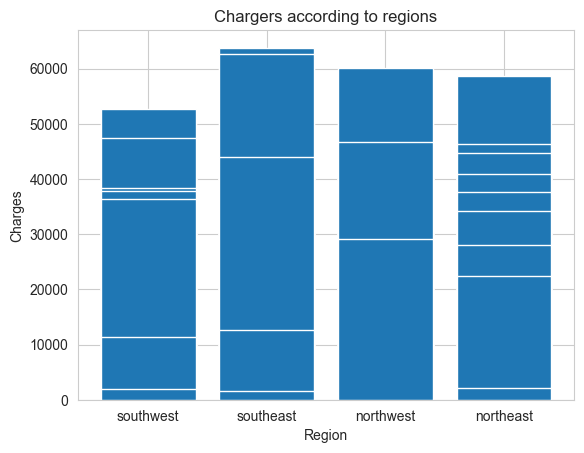

In [418]:
plt.bar(df['region'], df['charges'])
plt.title("Chargers according to regions")
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

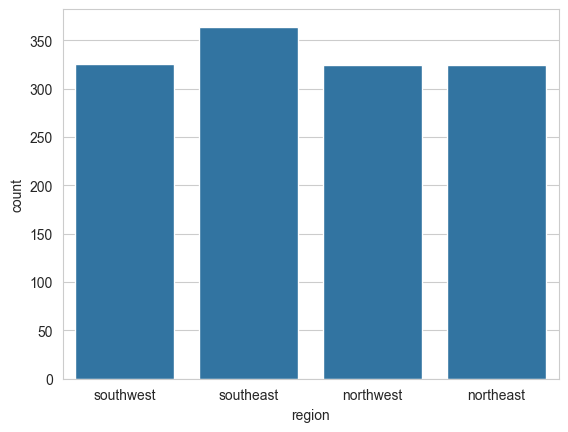

In [419]:
sns.countplot(x=df['region'])
plt.show()

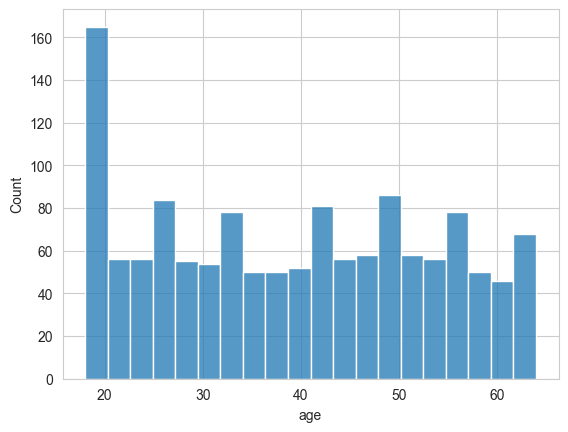

In [420]:
sns.histplot(df['age'], bins=20)
plt.show()

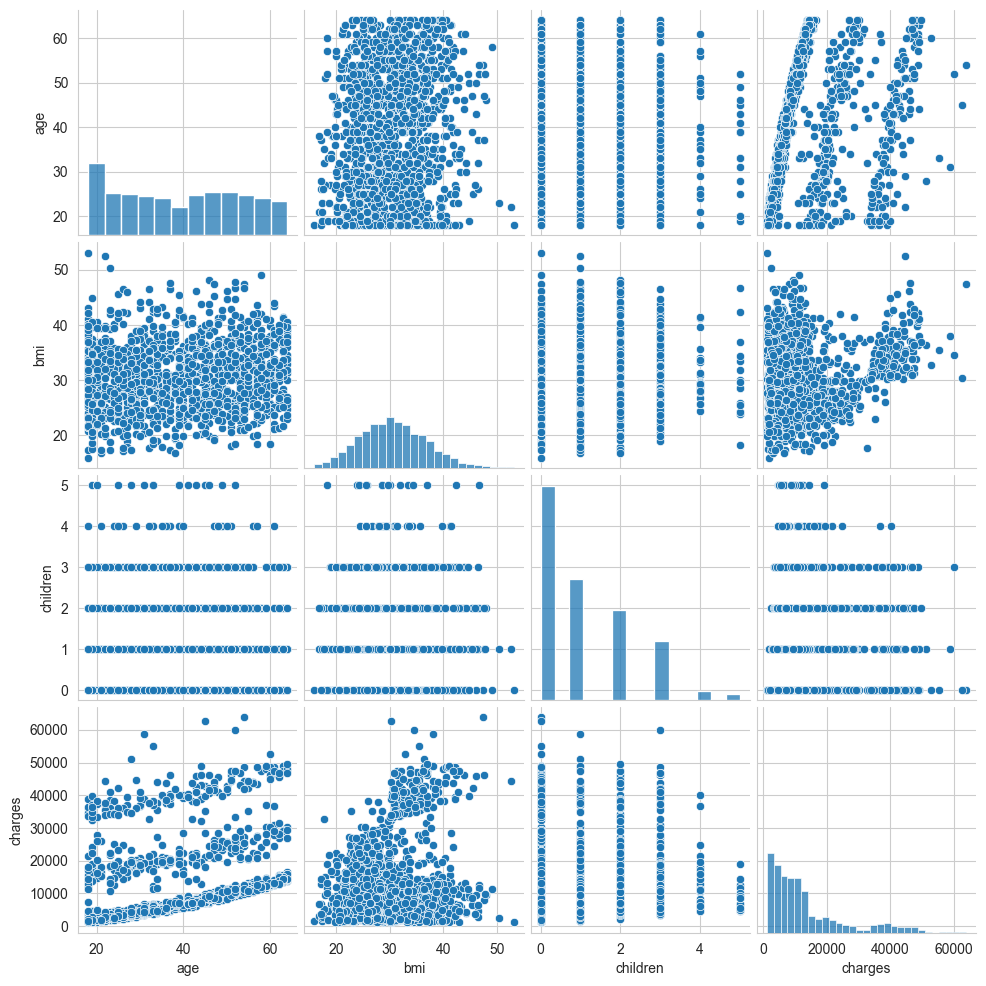

In [421]:
sns.pairplot(df)
plt.show()

In [422]:
from sklearn.preprocessing import LabelEncoder

print('Converting string into numerics')
encoder = LabelEncoder()

# sex, smoker, region 

for col in ['sex', 'smoker', 'region']:
    df[col] = encoder.fit_transform(df[col])
print('Conversion is successfull\n')
print('Moving to modelling part')

Converting string into numerics
Conversion is successfull

Moving to modelling part


In [423]:
df.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

In [424]:
print('Declaring Features and Targets')

x = df[['sex', 'smoker', 'region', 'bmi', 'age', 'children']]
y = df['charges']
print('Features and Targets are selected')

Declaring Features and Targets
Features and Targets are selected


# ***Decision tree(Base Model)***

Selecting model:
Model selected
Train Test Split performed
Training the model
Model trained
Predicting....
Prediction completed

checking the feature imprtance


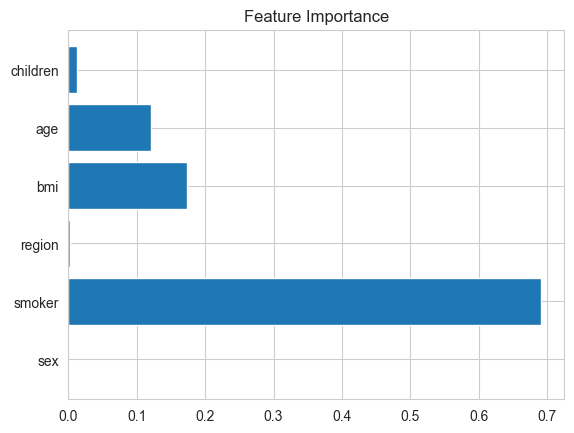

Visualizing the trees.....


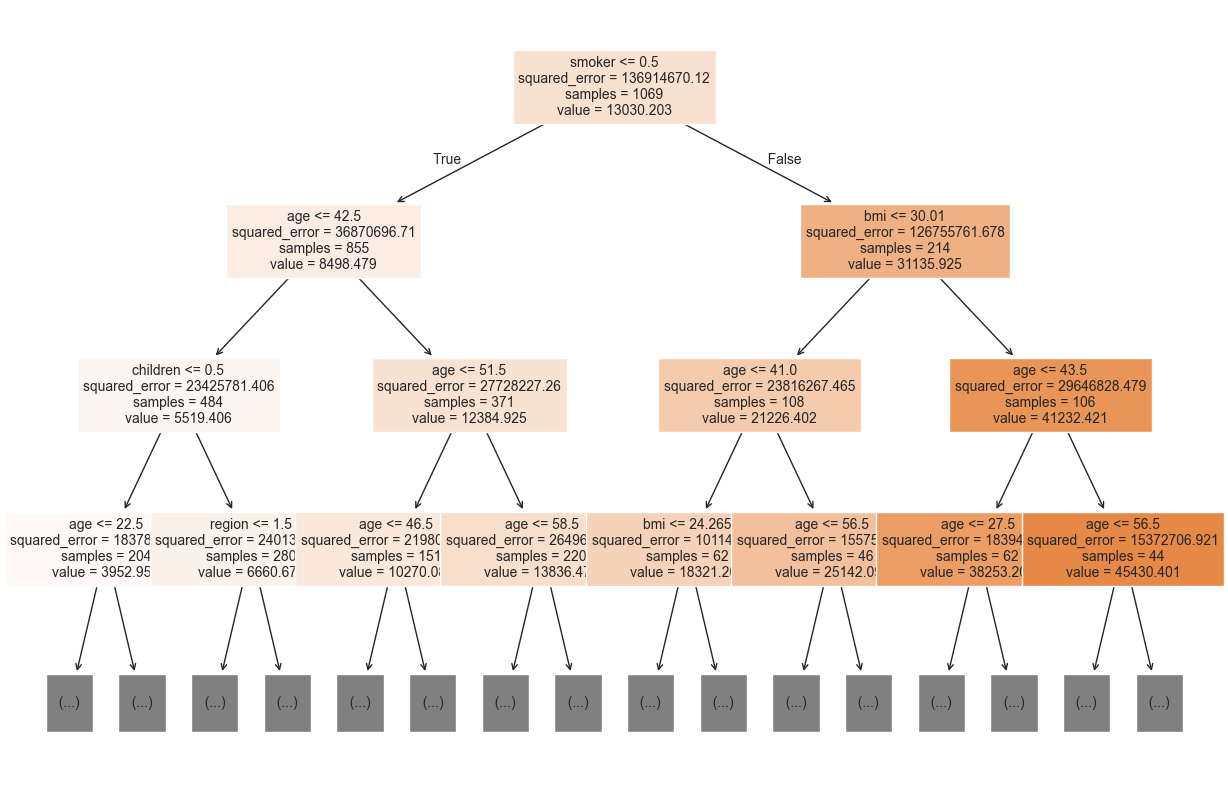

In [435]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

print("Selecting model:")
base_model = DecisionTreeRegressor(max_depth=5,
    min_samples_leaf=5,
    random_state=42)
print('Model selected')

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('Train Test Split performed')

print('Training the model')
base_model.fit(x_train, y_train)
print('Model trained')

print('Predicting....')
base_pred = base_model.predict(x_test)
print('Prediction completed\n')

print("checking the feature imprtance")
importance = base_model.feature_importances_
plt.barh(x.columns, importance)
plt.title("Feature Importance")
plt.show()

from sklearn import tree

print('Visualizing the trees.....')
plt.figure(figsize = (15,10))
tree.plot_tree(base_model,
    filled=True,
    max_depth=3,
    feature_names=x.columns,
    fontsize=10)
plt.show()

In [436]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

base_train_r2 = r2_score(y_train, base_model.predict(x_train))
print("R2 Score on trainin data: ",base_train_r2)
base_test_r2 = r2_score(y_test, base_pred)
print("R2 Score on test data: ", base_test_r2,'\n')

base_mae = mean_absolute_error(y_test, base_pred)
print("Mean abbsolute error is: ", base_mae)

base_mse = mean_squared_error(y_test, base_pred)
print("Mean squared error:", base_mse)
base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))
print("Root mean squared error:", base_rmse)


R2 Score on trainin data:  0.8671084815388432
R2 Score on test data:  0.8932706678391429 

Mean abbsolute error is:  2588.6656862884706
Mean squared error: 19612161.99561423
Root mean squared error: 4428.562068619365


# ***Grid Search CV(Tuned Model)***

In [437]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

print("Selecting parameters..")
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}
print("Parameter selected!\n")

print("Performing train test split..")
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train test split performed")

model = DecisionTreeRegressor(random_state=42)
print("Model selected\n")

print('Predicting....')
grid = GridSearchCV(model, param_grid, cv=5, scoring='r2')
grid.fit(x_train, y_train)

print('Prediction completed\n')

best_model = grid.best_estimator_
importance = best_model.feature_importances_
print('Best features are:')
pd.Series(importance, index=x_train.columns).sort_values(ascending=False)

Selecting parameters..
Parameter selected!

Performing train test split..
Train test split performed
Model selected

Predicting....
Prediction completed

Best features are:


smoker      0.689993
bmi         0.174629
age         0.120092
children    0.012822
region      0.002464
sex         0.000000
dtype: float64

In [438]:
tuned_model = grid.best_estimator_
tuned_pred = tuned_model.predict(x_test)

tuned_train_r2 = r2_score(y_train, tuned_model.predict(x_train))
tuned_test_r2 = r2_score(y_test, tuned_pred)
print("Tuned R2 Score on trainin data: ", tuned_train_r2)
print("Tuned R2 Score on testing data:", tuned_test_r2,'\n')

print("Best score on parameters:-")
print("Best Parameters:", grid.best_params_)
grid_search_score = grid.best_score_
print("Best Score:", grid_search_score,'\n')

Tuned R2 Score on trainin data:  0.8685296754684144
Tuned R2 Score on testing data: 0.892367145793449 

Best score on parameters:-
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Score: 0.8278423535806858 



# ***Comparison of both models***

In [439]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Base Decision Tree", "Tuned Decision Tree"],
    "Train R2": [base_train_r2, tuned_train_r2],
    "Test R2": [base_test_r2, tuned_test_r2]
})

print("\n===== FINAL MODEL COMPARISON =====")
print(comparison)


===== FINAL MODEL COMPARISON =====
                 Model  Train R2   Test R2
0   Base Decision Tree  0.867108  0.893271
1  Tuned Decision Tree  0.868530  0.892367


# ***Conclusion***

In [ ]:
print("\n===== CONCLUSION =====")

if tuned_test_r2 >= base_test_r2:
    print("Tuned model performed better.")
else:
    print("Base model performed slightly better on test data.\n")

print("Both models perform very similarly with minimal difference in R² scores.\n\
The base model slightly outperforms the tuned model on test data, \
and both models show good generalization as train and test scores are very close.")


===== CONCLUSION =====
Base model performed slightly better on test data.
Both models perform very similarly with minimal difference in R² scores.
The base model slightly outperforms the tuned model on test data, and both models show good generalization as train and test scores are very close.
